In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import anndata
import os
import tarfile
import seaborn as sb
import matplotlib.pyplot as plt
from matplotlib import rcParams
import warnings

#Thi is used because the horizontal scrolling was not working
#from IPython.display import display, HTML
#display(HTML("<style>.jp-OutputArea-output {display:flex}</style>"))

In [2]:
sc.set_figure_params(dpi=60, 
                     dpi_save=300, 
                     color_map= 'viridis_r', )
plt.rcParams['figure.figsize']=(6,6) #rescale figures
plt.rcParams['grid.alpha']=0
sc.settings.verbosity = 3
#sc.logging.print_header()

In [3]:
path= '0_raw_matrices/outs/count/filtered_feature_bc_matrix.h5'
adata= sc.read_10x_h5(path)
adata

reading 0_raw_matrices/outs/count/filtered_feature_bc_matrix.h5
 (0:00:02)


AnnData object with n_obs × n_vars = 70260 × 16629
    var: 'gene_ids', 'feature_types', 'genome'

In [4]:
adata.var['gene_ids']= adata.var['gene_ids'].str.replace('TcasGA2_', '', )
adata.var.set_index('gene_ids', inplace=True)
adata.var.index = adata.var.index.str.replace('tRNA-Val', 'mt:tRNA-Val') # I ddi not put the mt: in the begginig. I corrected it
adata.var

,feature_types,genome
gene_ids,,
TC031459,Gene Expression,Tcas5.2_cellranger_mkref
TC001593,Gene Expression,Tcas5.2_cellranger_mkref
TC001594,Gene Expression,Tcas5.2_cellranger_mkref
TC034512,Gene Expression,Tcas5.2_cellranger_mkref
TC004664,Gene Expression,Tcas5.2_cellranger_mkref
...,...,...
mt:ND1,Gene Expression,Tcas5.2_cellranger_mkref
mt:tRNA-Leu_2,Gene Expression,Tcas5.2_cellranger_mkref
mt:l-rRNA,Gene Expression,Tcas5.2_cellranger_mkref


In [5]:
###adding the annotated TF that I predicted
tf_predicted= pd.read_csv('2_TF_predicted/tribolium_output_true_annotated.csv', sep='\t', usecols=['sequence_ID'])
tf_list = set(tf_predicted['sequence_ID'])
print(f'The total nmber of predicted TFs is: {len(tf_list)}')
adata.var['is_TF'] = adata.var_names.isin(tf_list)
print(f'The number of predicted TFs found is: {len(adata.var[adata.var['is_TF'] == True])}')
#adata.var['is_TF'].value_counts()


The total nmber of predicted TFs is: 869
The number of predicted TFs found is: 869


In [6]:
#labeling samples
adata.obs['sample']= adata.obs_names.str.split('-').str[-1]
#adata.obs

In [7]:
ortholgs= pd.read_csv('1_eggnog_ortholgs/eggnog_orthologs_V3.csv', usecols=['gene_symbol', 'TC_seqs'])
filtered_df = ortholgs[ortholgs['TC_seqs'].str.count(';') == 0]
filtered_df['TC_seqs'] = filtered_df['TC_seqs'].str.extract(r'(TC\d+)-\w+')
unique_df = filtered_df.drop_duplicates(subset=['TC_seqs'])
unique_df.set_index('TC_seqs', inplace=True)
unique_df

/tmp/ipykernel_10843/1704730088.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['TC_seqs'] = filtered_df['TC_seqs'].str.extract(r'(TC\d+)-\w+')


,gene_symbol
TC_seqs,
TC000981,Ace
TC008433,ac
TC000889,Abd-B
TC013372,abo
TC000894,abd-A
...,...
TC030677,Topors
TC032389,Syx7
TC032354,PolD3


In [8]:
gene_info= adata.var[['feature_types', 'genome', 'is_TF']]

merged_df = pd.merge(gene_info, unique_df, how='left', left_index=True, right_index=True)

# Define a function to replace NaN values in "gene_symbol" column with values from index
def replace_nan_with_index(row):
    if pd.isnull(row['gene_symbol']):
        return row.name  # Using index value
    else:
        return row['gene_symbol']

# Apply the function to replace NaN values
merged_df['gene_names'] = merged_df.apply(replace_nan_with_index, axis=1)

# Drop the original "gene_symbol" column
merged_df.drop('gene_symbol', axis=1, inplace=True)
merged_df['original_TC_ids'] = merged_df.index
merged_df.set_index('gene_names', inplace=True)

# Print the resulting DataFrame
#merged_df
adata.var = merged_df
adata.var

,feature_types,genome,is_TF,original_TC_ids
gene_names,,,,
TC031459,Gene Expression,Tcas5.2_cellranger_mkref,False,TC031459
Hey,Gene Expression,Tcas5.2_cellranger_mkref,True,TC001593
Asph,Gene Expression,Tcas5.2_cellranger_mkref,False,TC001594
TppII,Gene Expression,Tcas5.2_cellranger_mkref,False,TC034512
TC004664,Gene Expression,Tcas5.2_cellranger_mkref,False,TC004664
...,...,...,...,...
mt:ND1,Gene Expression,Tcas5.2_cellranger_mkref,False,mt:ND1
mt:tRNA-Leu_2,Gene Expression,Tcas5.2_cellranger_mkref,False,mt:tRNA-Leu_2
mt:l-rRNA,Gene Expression,Tcas5.2_cellranger_mkref,False,mt:l-rRNA


In [9]:
adata.var_names_make_unique ()
adata.obs_names_make_unique ()

In [10]:
#Identif the ribosomal genes
for idx, gene_name in enumerate(adata.var.index):
    if gene_name.startswith('RpS') or gene_name.startswith('RpL'):
        # Add the prefix 'Ribo:' to genes starting with 'RpS' or 'RpL'
        adata.var.index.values[idx] = 'ribo:' + gene_name


In [11]:
adata.var["ribo"] = adata.var_names.str.startswith("ribo:")
adata.var["mt"] = adata.var_names.str.startswith("mt:")

sc.pp.calculate_qc_metrics(adata, qc_vars=['ribo', 'mt'], inplace=True)

In [12]:
sc.pp.scrublet(adata, batch_key="sample")

Running Scrublet
filtered out 3609 genes that are detected in less than 3 cells
normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
normalizing counts per cell
    finished (0:00:00)
normalizing counts per cell
    finished (0:00:00)
Embedding transcriptomes using PCA...
    using data matrix X directly
Automatically set threshold at doublet score = 0.31
Detected doublet rate = 0.0%
Estimated detectable doublet fraction = 0.1%
Overall doublet rate:
	Expected   = 5.0%
	Estimated  = 18.2%
filtered out 2238 genes that are detected in less than 3 cells
normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata

In [13]:
adata.var

,feature_types,genome,is_TF,original_TC_ids,ribo,mt,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts
gene_names,,,,,,,,,,,,
TC031459,Gene Expression,Tcas5.2_cellranger_mkref,False,TC031459,False,False,14799,0.700185,0.530737,78.936806,49195.0,10.803568
Hey,Gene Expression,Tcas5.2_cellranger_mkref,True,TC001593,False,False,9061,0.270609,0.239496,87.103615,19013.0,9.852931
Asph,Gene Expression,Tcas5.2_cellranger_mkref,False,TC001594,False,False,4823,0.085995,0.082497,93.135497,6042.0,8.706656
TppII,Gene Expression,Tcas5.2_cellranger_mkref,False,TC034512,False,False,9633,0.179263,0.164889,86.289496,12595.0,9.441134
TC004664,Gene Expression,Tcas5.2_cellranger_mkref,False,TC004664,False,False,6930,0.122673,0.115712,90.136635,8619.0,9.061840
...,...,...,...,...,...,...,...,...,...,...,...,...
mt:ND1-1,Gene Expression,Tcas5.2_cellranger_mkref,False,mt:ND1,False,True,41854,1.883675,1.059065,40.429832,132347.0,11.793190
mt:tRNA-Leu_2,Gene Expression,Tcas5.2_cellranger_mkref,False,mt:tRNA-Leu_2,False,True,50,0.000754,0.000754,99.928836,53.0,3.988984
mt:l-rRNA,Gene Expression,Tcas5.2_cellranger_mkref,False,mt:l-rRNA,False,True,69936,48.357230,3.899084,0.461144,3397579.0,15.038574


In [14]:
##To check which are the mitochondrial and ribosomal genes
#adata.var.query('ribo == True')

In [15]:
#thisis just for comparison before and after filtering
df1= adata.copy()
df1

AnnData object with n_obs × n_vars = 70260 × 16629
    obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'doublet_score', 'predicted_doublet'
    var: 'feature_types', 'genome', 'is_TF', 'original_TC_ids', 'ribo', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'scrublet'

In [16]:

## creating a boxplot to show the data distribution
def range_values_in_dataset (plot_title='Non normalized dataset'):
    tmp1=pd.DataFrame(adata.X)
    uniques=np.unique (tmp1)
    outliers_annotations = dict(markerfacecolor='g', marker='D', markersize=4, alpha=0.1,)
    box_annotations= dict(linewidth=1, color='blue', alpha=0.9 , facecolor='teal' )
    plt.boxplot (uniques, patch_artist=True, 
                 flierprops=outliers_annotations, 
                 boxprops= box_annotations )
    plt.ylabel('Unique range of values in the dataset ')
    plt.title (plot_title) ## you can notice it because the range is large
    plt.tick_params(labelbottom=False, bottom=False)
    sb.displot(uniques, kind="kde", legend=False)
    plt.tick_params(labelleft=False, left=False, )
    del uniques, tmp1

# creating QC violin plots   
def qc_violin_plots (xvalue='genotype', xlabels=False, jitter=0.25, size=1.5):
    fig, axs = plt.subplots(ncols=4, figsize=(18,5),
                            constrained_layout=True ) #multipanel Fig

    fig = sb.violinplot(x=adata.obs[xvalue], 
                        y=adata.obs['n_genes_by_counts'],
                        data=adata.obs, ax=axs[0])
    fig= sb.stripplot(x=adata.obs[xvalue], 
                      y=adata.obs['n_genes_by_counts'], 
                      data=adata.obs, jitter=jitter, 
                      color='black', size=size, ax=axs[0])
    fig.axes.get_xaxis().set_visible(xlabels)
    fig.set_title('number of genes', fontweight ='bold')

    fig1 = sb.violinplot(x=adata.obs[xvalue],
                         y=adata.obs['total_counts'],
                         data=adata.obs, ax=axs[1])
    fig1= sb.stripplot(x=adata.obs[xvalue],
                       y=adata.obs['total_counts'],
                       data=adata.obs, jitter=jitter,
                       color='black', size=size,ax=axs[1])
    fig1.axes.get_xaxis().set_visible(xlabels)
    fig1.set_title('total counts', fontweight ='bold')


    fig2 = sb.violinplot(x=adata.obs[xvalue],
                         y=adata.obs['pct_counts_ribo'],
                         data=adata.obs, ax=axs[2])
    fig2= sb.stripplot(x=adata.obs[xvalue],
                       y=adata.obs['pct_counts_ribo'],
                       data=adata.obs, jitter=jitter, 
                       color='black', ax=axs[2], 
                       size=size, marker="D")
    fig2.axes.get_xaxis().set_visible(xlabels)
    fig2.set_title('% Ribosomal counts', fontweight ='bold')
    
    fig3 = sb.violinplot(x=adata.obs[xvalue],
                         y=adata.obs['pct_counts_mt'],
                         data=adata.obs, ax=axs[3])
    fig3= sb.stripplot(x=adata.obs[xvalue],
                       y=adata.obs['pct_counts_mt'],
                       data=adata.obs, jitter=jitter, 
                       color='black', ax=axs[3], 
                       size=size, marker="D")
    fig3.axes.get_xaxis().set_visible(xlabels)
    fig3.set_title('% mitochondrial counts', fontweight ='bold')
    
# creating QC scatter plots   
def qc_scatter_plots (cells_to_filter=30000,genes_to_filter=700):
    fig, axs = plt.subplots(ncols=2, figsize=(15,6), 
                            constrained_layout=True, sharey=False, sharex=False )
    p0 = axs[0].scatter(x=adata.obs['total_counts'],
                   y=adata.obs['n_genes_by_counts'],
                   c=adata.obs['pct_counts_mt'],
                   cmap="rainbow",
                   s=0.1)
    axs[0].set_xlabel('total_counts')
    axs[0].set_ylabel('n_genes')
    axs[0].set_title('% mitochondrial counts')
    axs[0].axvline(cells_to_filter, color='red') ####This is the min_counts to filter
    fig.colorbar(p0, 
                 aspect=50,
                 ax=axs[0],
                 pad=0)

    #Ploting a reduced number of cells filtered by n_counts
    obtaining_obs_to_plot = sc.get.obs_df(adata, 
                                          ['total_counts', 'n_genes_by_counts', 'pct_counts_mt'])
    reduced_num_cells= obtaining_obs_to_plot[obtaining_obs_to_plot['total_counts'] < cells_to_filter]
    p1 = axs[1].scatter(x=reduced_num_cells['total_counts'],
                   y=reduced_num_cells['n_genes_by_counts'],
                   c=reduced_num_cells['pct_counts_mt'],
                   cmap="rainbow",
                   s=0.1)

    axs[1].set_xlabel('total_counts')
    axs[1].set_ylabel('n_genes')
    axs[1].set_title('% mitochondrial counts')
    axs[1].axhline(y=genes_to_filter, color='red') ####This is the min_counts to filter
    fig.colorbar(p1,
                 aspect=50,
                 ax=axs[1],
                 pad=0)
    
    total_cells_label=int (adata.obs['total_counts'].shape[0] )
    reduced_cells_label= reduced_num_cells.shape[0]
    above_cells= total_cells_label-reduced_cells_label
    text1= f'{total_cells_label} cells.\n{reduced_cells_label} below \n{above_cells} above'
    
    reduced_num_cells2=reduced_num_cells[reduced_num_cells['n_genes_by_counts'] > genes_to_filter]
    below_cells_genes= reduced_num_cells.shape[0] - reduced_num_cells2.shape[0]
    text2= f'{reduced_cells_label} cells \n {reduced_num_cells2.shape[0]} above \n{below_cells_genes} below'
    axs[0].text(50000,3500, text1 )
    axs[1].text(12000,3000, text2 ,horizontalalignment='right')

# creating QC scatter plots2   
def qc_scatter_plots2 (mt_percentage=5):
    fig, axs = plt.subplots(ncols=2, figsize=(15,6), 
                            constrained_layout=True, sharey=False, sharex=False )
    p0 = axs[0].scatter(x=adata.obs['total_counts'],
                   y=adata.obs['pct_counts_ribo'],
                   c=adata.obs['n_genes_by_counts'],
                   # cmap="rainbow",
                   s=0.1)
    axs[0].set_xlabel('total_counts')
    axs[0].set_ylabel('% Ribosomal counts')
    axs[0].set_title('% Ribosomal counts')
    axs[0].axhline(mt_percentage, color='red') #### This is the min_counts to filter
    fig.colorbar(p0, 
                 aspect=50,
                 ax=axs[0],
                 pad=0)
    
    
    # Ploting a reduced number of cells filtered by n_counts
    p1 = axs[1].scatter(x=adata.obs['n_genes_by_counts'],
                   y=adata.obs['pct_counts_ribo'],
                   c=adata.obs['total_counts'],
                   #cmap="rainbow",
                   s=0.1)

    axs[1].set_xlabel('n_genes')
    axs[1].set_ylabel('% Ribo counts')
    axs[1].set_title('% Ribo counts')
    axs[1].axhline(mt_percentage, color='red') #### This is the min_counts to filter
    fig.colorbar(p1,
                 aspect=50,
                 ax=axs[1],
                 pad=0)
    
    obtaining_obs_to_plot = sc.get.obs_df(adata, 
                                          ['total_counts', 'n_genes_by_counts', 'pct_counts_ribo'])
    reduced_num_cells= obtaining_obs_to_plot[obtaining_obs_to_plot['pct_counts_ribo'] < mt_percentage]
    total_cells_label=int (adata.obs['pct_counts_ribo'].shape[0] )
    reduced_cells_label= reduced_num_cells.shape[0]
    above_cells= total_cells_label-reduced_cells_label
    text1= f'{total_cells_label} cells.\n{reduced_cells_label} below \n{above_cells} above'
    axs[0].text(30000,11, text1 )    
    

# creating QC counts distribution plots   
def qc_counts_distribution_plot (min_counts=1200, max_counts=15000):
    # Thresholding decision: counts
    fig, axs = plt.subplots(ncols=3, figsize=(15,6), 
                            constrained_layout=True ) #multipanel Fig

    p3 = sb.histplot(adata.obs['total_counts'],
                     kde=True, bins=200,ax=axs[0])
    p3.axvline(min_counts, color='red')
    p3.axvline(max_counts, color='red')
    p3.set_xlim (xmin=0, xmax=60000)          # xmax=40000
    p3.set_ylabel('# cells')
    p3.set_xlabel('total counts')


    p4 = sb.histplot(adata.obs['total_counts'][adata.obs['total_counts']<5000],
                     kde=False, bins=100, ax=axs[1])
    #p4.axvline(400, color='yellow')
    p4.axvline(min_counts, color='red') ####This is the min_counts to filter
    p4.set_xlim (xmin=0, )          
    p4.set_ylabel('# cells')
    p4.set_xlabel('total counts')

    p5 = sb.histplot(adata.obs['total_counts'][adata.obs['total_counts']>5000],
                     kde=False, ax=axs[2])
    p5.set_xlim (xmax=60000, )          
    p5.set_ylabel('# cells')
    p5.set_xlabel('total counts')
    p5.axvline(max_counts, color='red') ####This is the max_counts to filter


    total_cells_label=int (adata.obs['total_counts'].shape[0] )
    below_label=adata.obs['total_counts'][adata.obs['total_counts']<min_counts].shape[0]
    above_label=adata.obs['total_counts'][adata.obs['total_counts']>max_counts].shape[0]
    filter_label=total_cells_label- (below_label+above_label)
    text1= f'{total_cells_label} cells.\n{below_label} below \n{above_label} above \n{filter_label} remaining'
    axs[0].text(7000,3000, text1 )

# creating QC genes distribution plots   
def qc_genes_distribution_plot (min_genes=700):
    #Thresholding decision: genes
    fig, axs = plt.subplots(ncols=2, figsize=(15,6),
                            constrained_layout=True, ) #multipanel Fig

    p6 = sb.histplot(adata.obs['n_genes_by_counts'],
                     kde=True, ax=axs[0])
    p6.axvline(min_genes, color='red')
    p6.set_ylabel('# cells')
    p6.set_xlabel('number of genes')

    p7 = sb.histplot(adata.obs['n_genes_by_counts'][adata.obs['n_genes_by_counts']<1000],
                     kde=False, ax=axs[1])
    #p7.axvline(40, color='yellow')
    p7.axvline(min_genes, color='red')####This is the min_genes to filter
    p7.set_ylabel('# cells')
    p7.set_xlabel('number of genes')

    total_cells_label=int (adata.obs['n_genes_by_counts'].shape[0])
    below_label= adata.obs['n_genes_by_counts'][adata.obs['n_genes_by_counts']<min_genes].shape[0]
    filter_label=total_cells_label - below_label
    text1= f'{total_cells_label} cells.\n{below_label} below \n{filter_label} remaining'
    axs[0].text(2000,1000, text1 )
    

# Test different QC genes filters and plot the results without actually filtering   
def filtering_parameters (adata, 
                          min_counts=1500,
                          max_counts = 25000,
                          mt_percentage= 13,
                          min_genes = 500,
                          min_cells=10):
    '''Review multiple filtering parameters'''
    sc.settings.verbosity = 0
    shape(adata)

    sc.pp.filter_cells(adata, min_counts = min_counts)
    print('Number of cells after min_count filter: {:d}'.format(adata.n_obs))

    sc.pp.filter_cells(adata, max_counts = max_counts)
    print('Number of cells after max_count filter: {:d}'.format(adata.n_obs))

    adata = adata[adata.obs['pct_counts_mt'] < mt_percentage]
    print('Number of cells after MT_filter: {:d}'.format(adata.n_obs))

    sc.pp.filter_cells(adata, min_genes = min_genes)
    print('Number of cells after min gene filter: {:d}'.format(adata.n_obs))

    #Filtering GENES:
    print('Total number of genes: {:d}'.format(adata.n_vars))

    # Min 20 cells - filters out 0 count genes
    sc.pp.filter_genes(adata, min_cells=min_cells)
    print('Number of genes after cell filter: {:d}'.format(adata.n_vars))

    # See how many cells and genes left after filtering
    shape(adata)
    
    #Data quality summary plots
    sc.pl.scatter(adata, 'total_counts',
                   'n_genes_by_counts',
                   color='pct_counts_ribo',
                   title= f'{mt_percentage}% mitochondrial counts after filtering',
                   color_map='rainbow', )


#Check how many genes form the ones we want to analyze remain after filtering
def genes_in_dataset (genes_list, dataset,):
    global found_genes
    global no_found_genes
    found_genes=[]
    no_found_genes=[]
    for gene in genes_list:
        if gene in dataset.raw.var_names:
            found_genes.append (gene)
        else:
            no_found_genes.append (gene, )
    #return found_genes, no_found_genes
    print (f'We found {len (found_genes)} out of {len(ALL_GENES)}')
    print (f'These genes are not in the datset: {no_found_genes}')
    
# print shape of the matrix 
def shape(adata):
    print ('In the dataset there are:')
    print (f'{adata.obs.shape[0]} cells')
    print (f'{adata.var.shape[0]} genes')

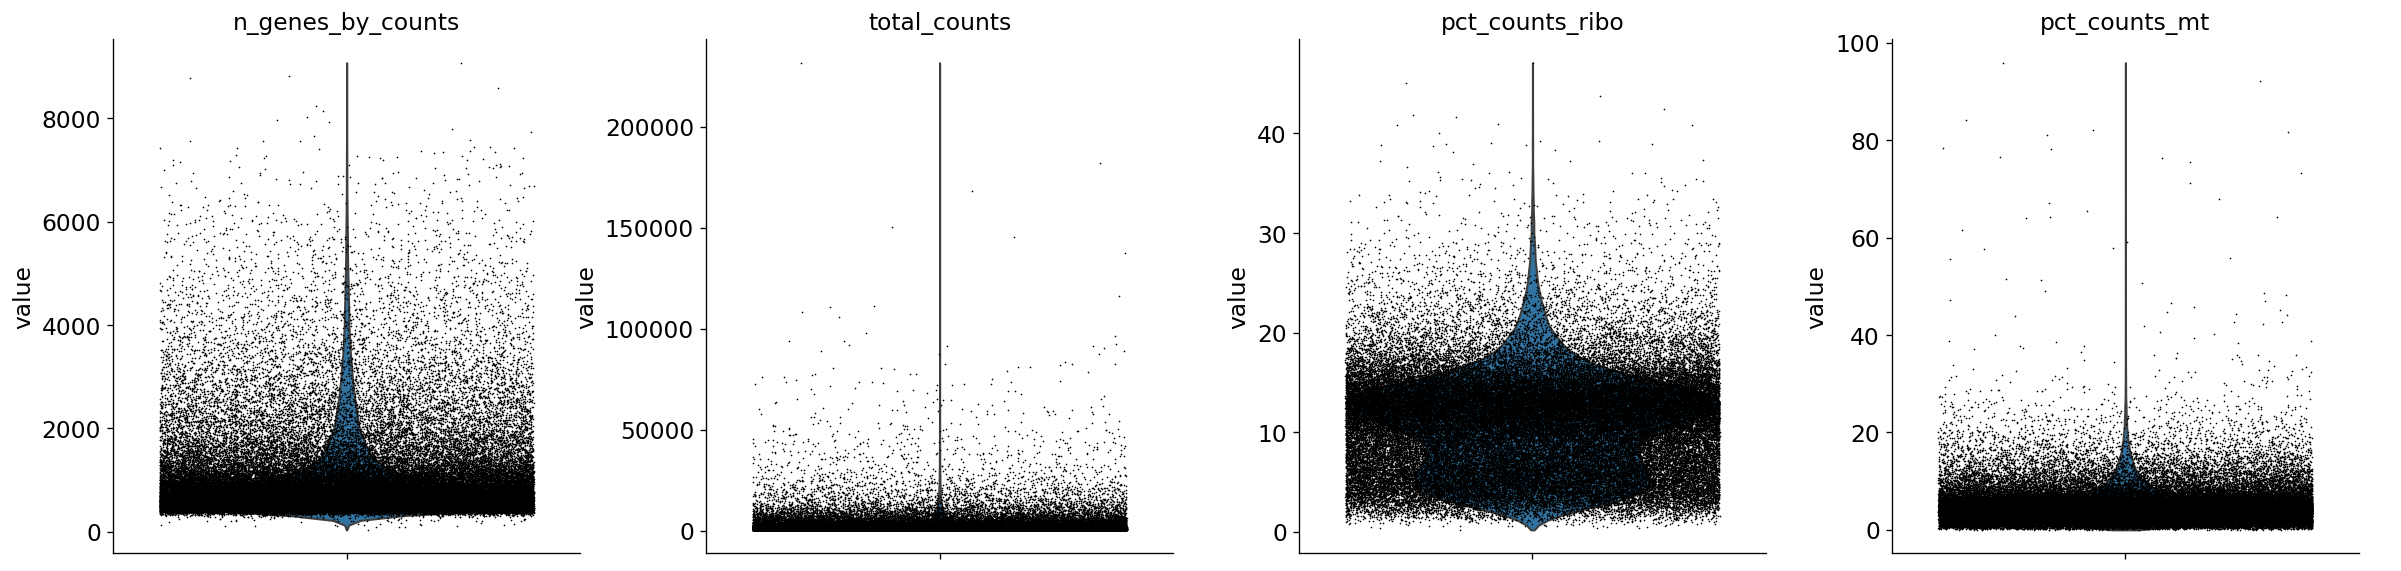

In [17]:
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_ribo', 'pct_counts_mt'],
             jitter=0.4, multi_panel=True, save='QC_violin_plots_1.pdf')

## Note: this plot was not working correctly in scanpy 1.6
## So I wrote my verion that you can see in the function qc_violin_plots ().
## So now both functions are working

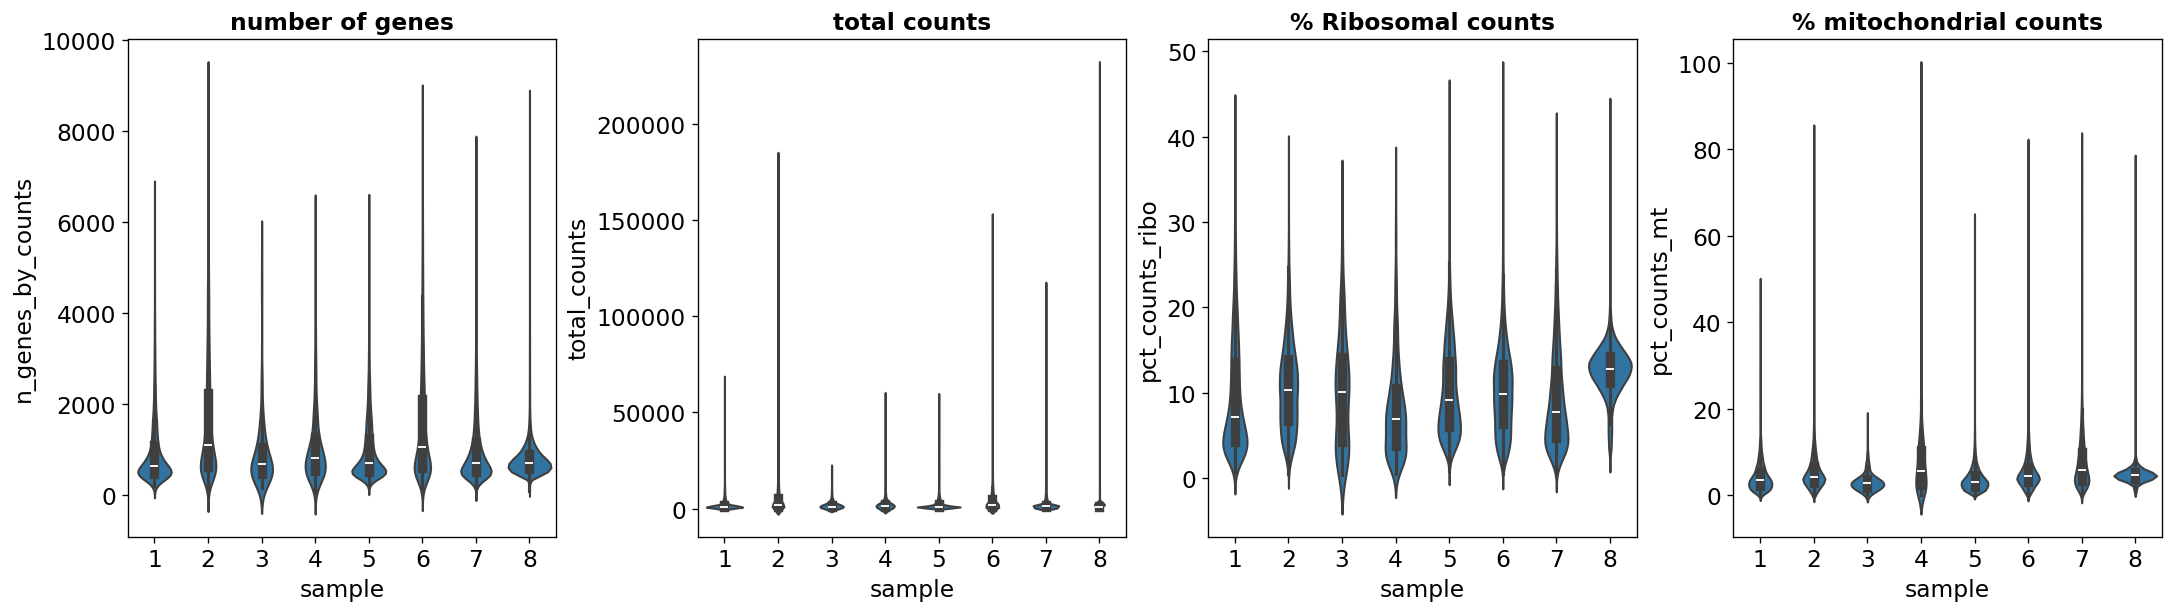

In [18]:
qc_violin_plots (xvalue='sample', xlabels=True, size=0)

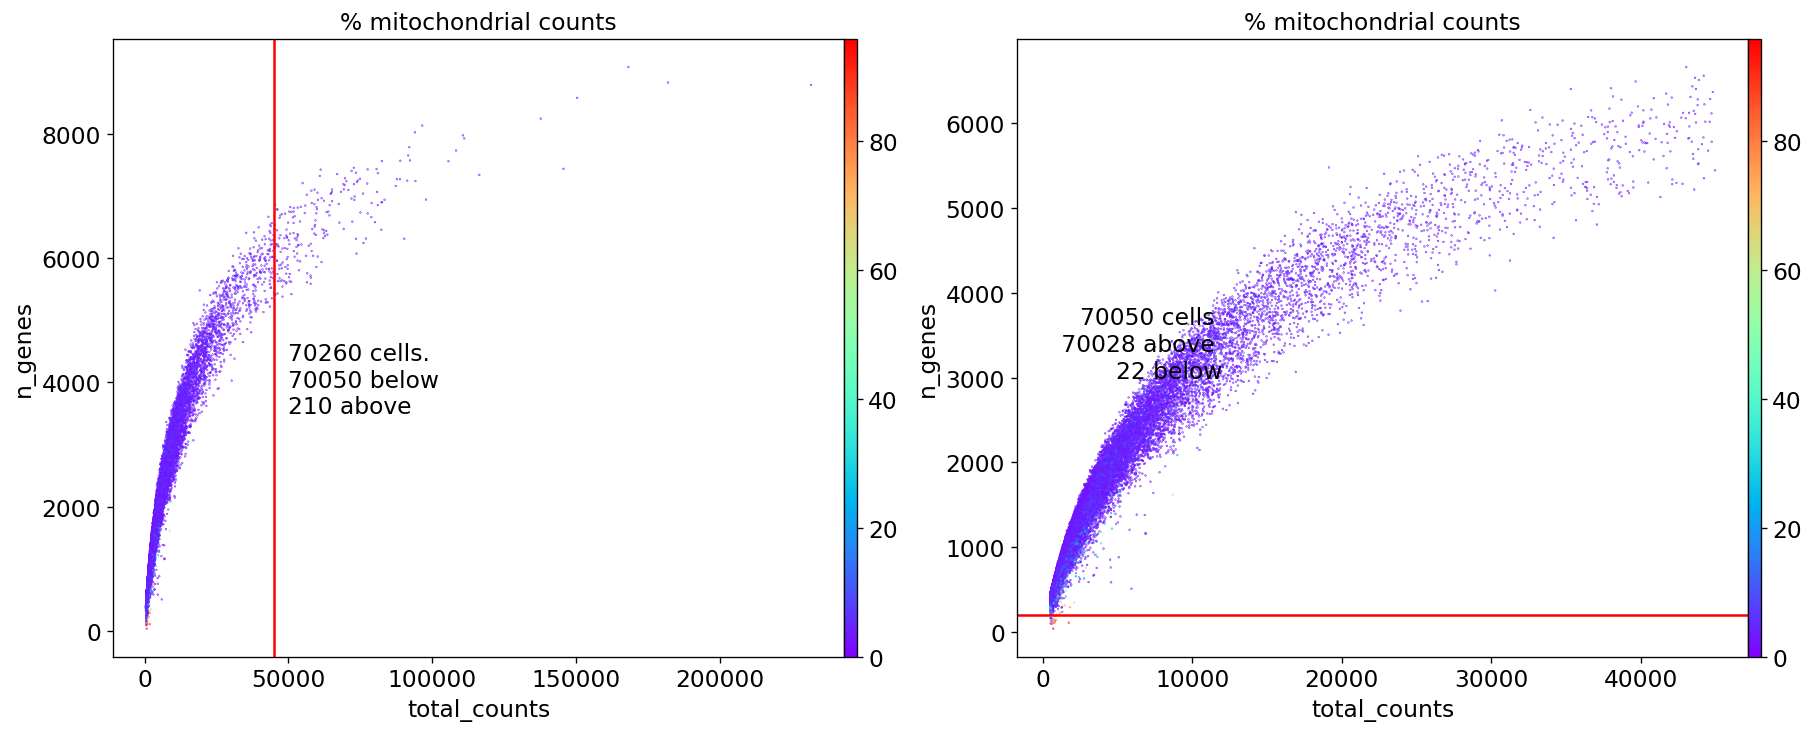

In [19]:
qc_scatter_plots (cells_to_filter=45000, genes_to_filter=200)

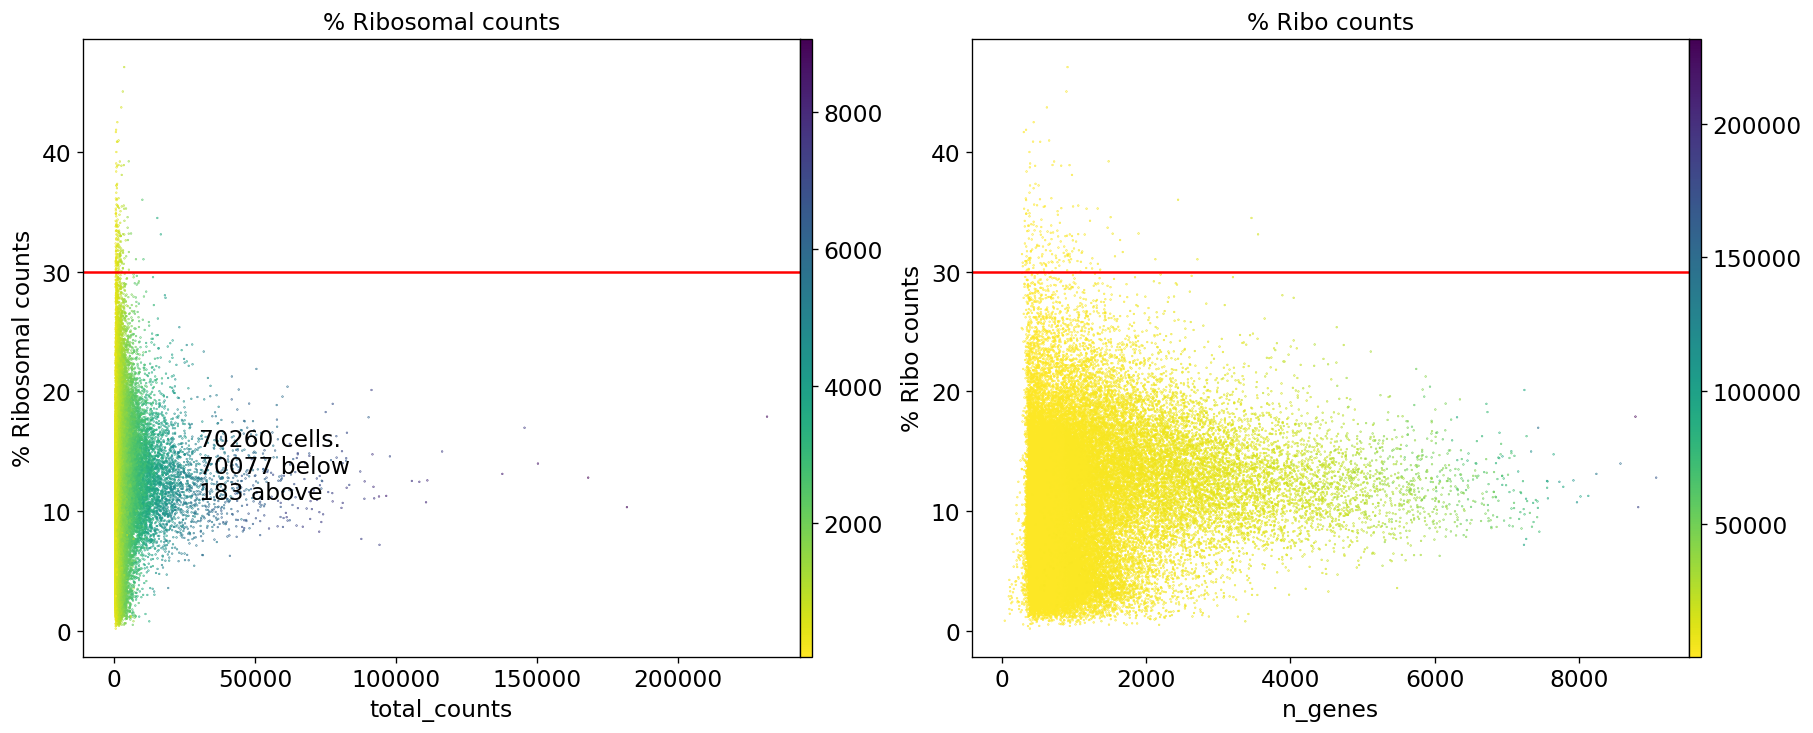

In [20]:
qc_scatter_plots2(mt_percentage=30)

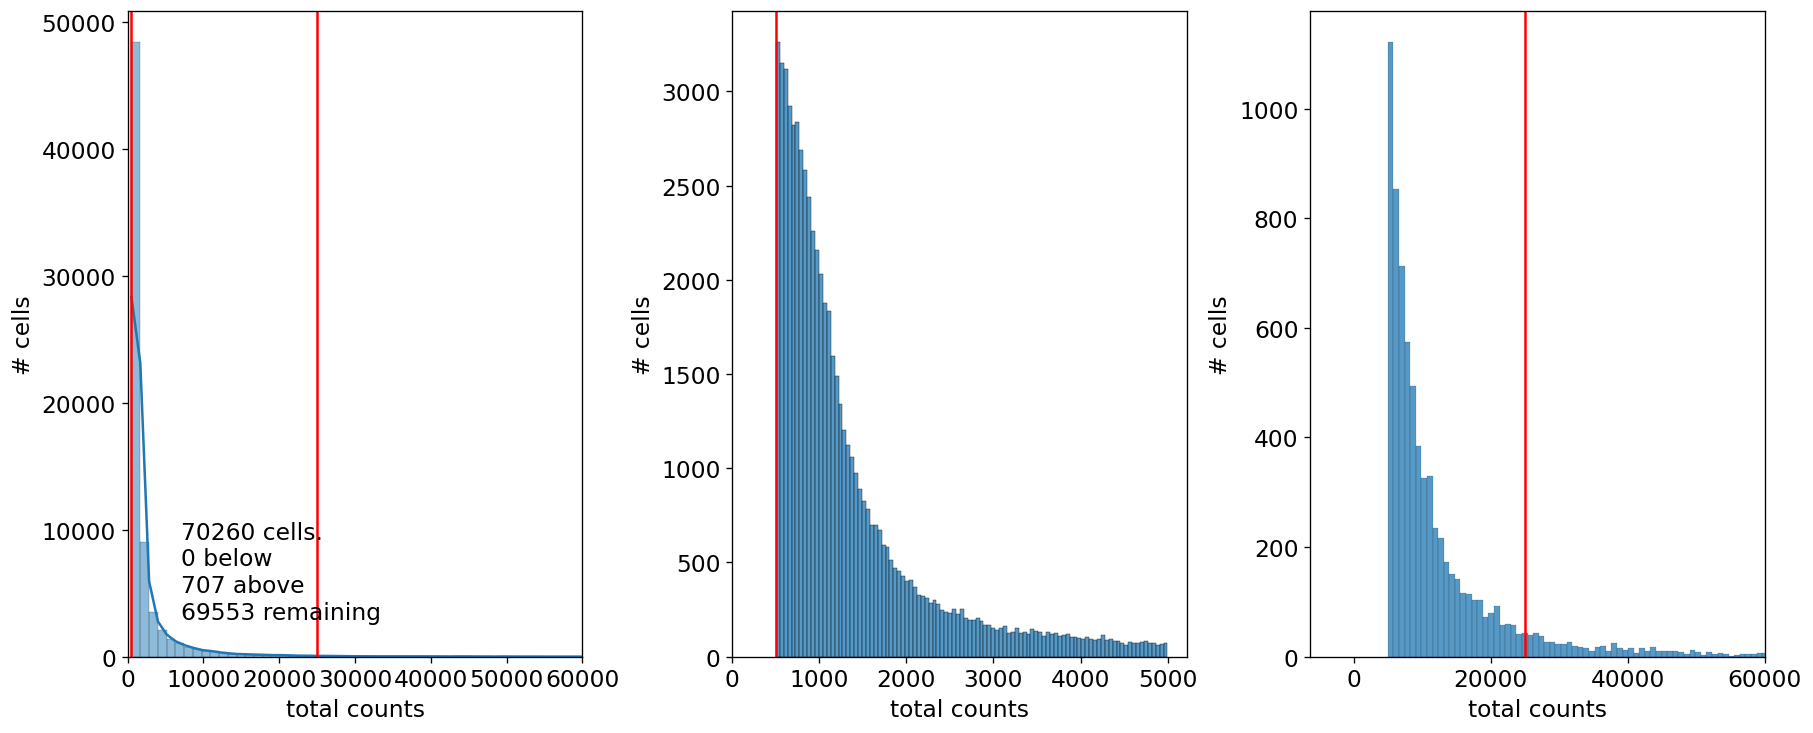

In [21]:
qc_counts_distribution_plot (min_counts=500, max_counts=25000)

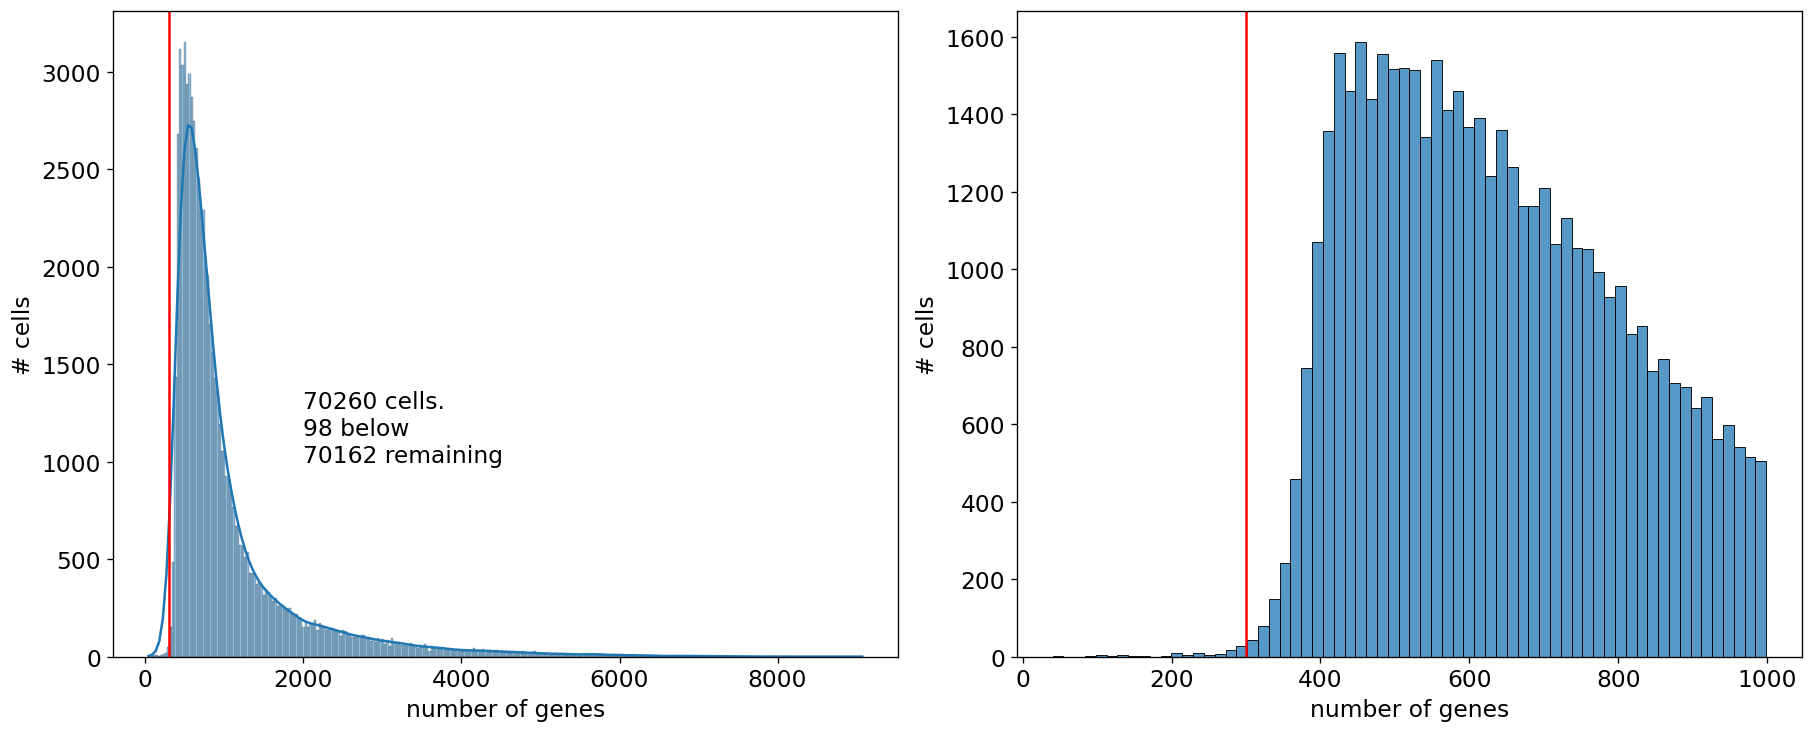

In [22]:
qc_genes_distribution_plot (min_genes=300)

In the dataset there are:
70260 cells
16629 genes
Number of cells after min_count filter: 70260
filtered out 154 cells that have more than (50000,) counts
Number of cells after max_count filter: 70106
Number of cells after MT_filter: 69862
Number of cells after Ribo_filter: 69862
filtered out 61 cells that have less than (300,) genes expressed


/home/beetle/miniconda3/envs/scanpy_001/lib/python3.12/site-packages/scanpy/preprocessing/_simple.py:170: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["n_genes"] = number


Number of cells after min gene filter: 69801
Total number of genes: 16629
filtered out 2058 genes that are detected in less than 10 cells
Number of genes after cell filter: 14571
In the dataset there are:
69801 cells
14571 genes


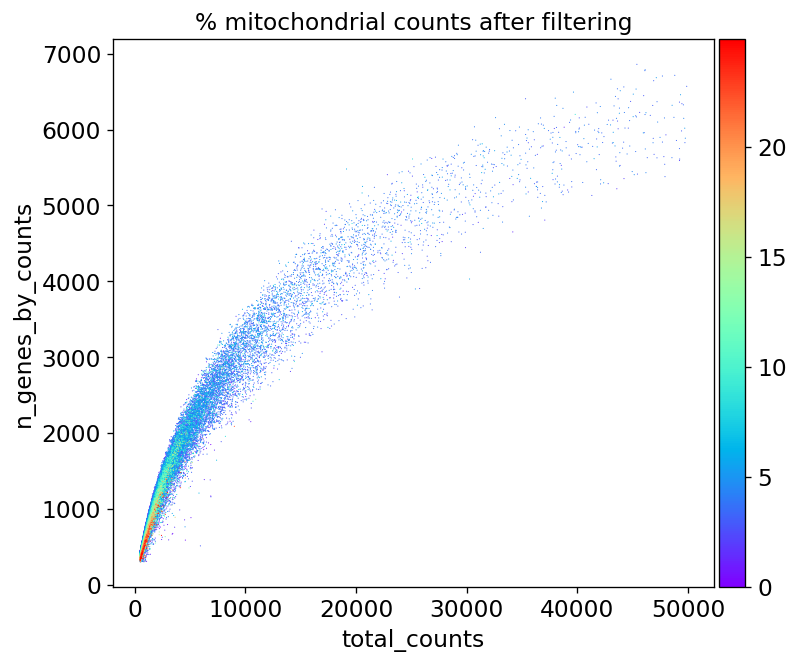

In [23]:
## Filtering CELLS according to identified quality control thresholds
#values to filter
min_counts=500,
max_counts = 50000,
mt_percentage= 25,
ribo_percentage= 50,
min_genes = 300,
min_cells=10

shape(adata)

sc.pp.filter_cells(adata, min_counts = min_counts)
print('Number of cells after min_count filter: {:d}'.format(adata.n_obs))

sc.pp.filter_cells(adata, max_counts = max_counts)
print('Number of cells after max_count filter: {:d}'.format(adata.n_obs))

adata = adata[adata.obs['pct_counts_mt'] < mt_percentage]
print('Number of cells after MT_filter: {:d}'.format(adata.n_obs))

adata = adata[adata.obs['pct_counts_ribo'] < ribo_percentage]
print('Number of cells after Ribo_filter: {:d}'.format(adata.n_obs))

sc.pp.filter_cells(adata, min_genes = min_genes)
print('Number of cells after min gene filter: {:d}'.format(adata.n_obs))

#Filtering GENES:
print('Total number of genes: {:d}'.format(adata.n_vars))

# Min 20 cells - filters out 0 count genes
sc.pp.filter_genes(adata, min_cells=min_cells)
print('Number of genes after cell filter: {:d}'.format(adata.n_vars))

# See how many cells and genes left after filtering
shape(adata)
    
#Data quality summary plots
sc.pl.scatter(adata, 'total_counts',
              'n_genes_by_counts',
               color='pct_counts_mt',
               title='% mitochondrial counts after filtering',
               color_map='rainbow', )

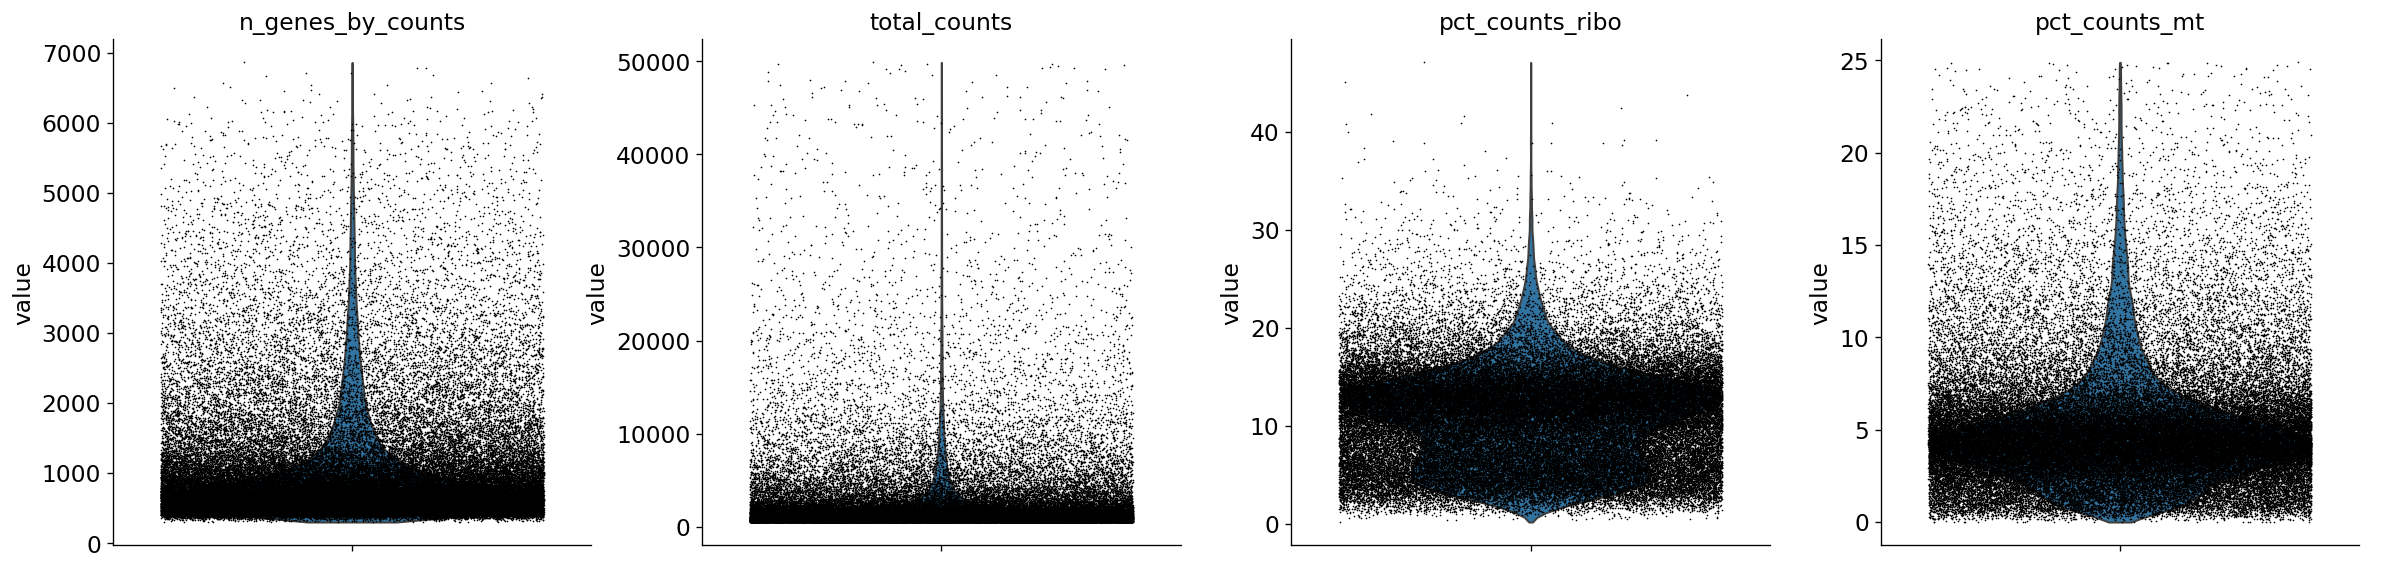

In [24]:
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_ribo', 'pct_counts_mt'],
             jitter=0.4, multi_panel=True, save='QC_violin_plots_2.pdf')


In [25]:
adata

AnnData object with n_obs × n_vars = 69801 × 14571
    obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'doublet_score', 'predicted_doublet', 'n_counts'
    var: 'feature_types', 'genome', 'is_TF', 'original_TC_ids', 'ribo', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    uns: 'scrublet'

In [26]:
#Removing mitochondrial counts from the analysis
mt_genes_list= list(adata.var[(adata.var['mt']== True)].index)
mt_genes=np.in1d (adata.var_names.values.astype(str), mt_genes_list)
adata= adata[:, ~mt_genes]
adata

/tmp/ipykernel_10843/3386185150.py:3: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  mt_genes=np.in1d (adata.var_names.values.astype(str), mt_genes_list)


View of AnnData object with n_obs × n_vars = 69801 × 14525
    obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'doublet_score', 'predicted_doublet', 'n_counts'
    var: 'feature_types', 'genome', 'is_TF', 'original_TC_ids', 'ribo', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    uns: 'scrublet'

In [27]:
#Removing ribosomal counts from the analysis
ribo_genes_list= list(adata.var[(adata.var['ribo']== True)].index)
ribo_genes=np.in1d (adata.var_names.values.astype(str), ribo_genes_list)
adata= adata[:, ~ribo_genes]
adata

/tmp/ipykernel_10843/1979858822.py:3: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  ribo_genes=np.in1d (adata.var_names.values.astype(str), ribo_genes_list)


View of AnnData object with n_obs × n_vars = 69801 × 14455
    obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'doublet_score', 'predicted_doublet', 'n_counts'
    var: 'feature_types', 'genome', 'is_TF', 'original_TC_ids', 'ribo', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    uns: 'scrublet'

In [28]:
#saving layer of normalized data that can be used for differential expression
adata.raw = adata
#creating a new layer
adata.layers["counts"] = adata.raw.X.copy()

In [29]:
##Normalization with scanpy method (CPM normalization)
#normalize to depth 10000
sc.pp.normalize_total(adata,
                      target_sum=1e6, 
                      key_added= 'norm',)

normalizing counts per cell
    finished (0:00:00)


In [30]:
#logaritmize
sc.pp.log1p(adata)

In [31]:
shape (adata)

In the dataset there are:
69801 cells
14455 genes


In [32]:
'''

# df1 was created early in the analysis
df= pd.DataFrame(df1.obs['sample'].value_counts())
df['cells'] = 'before'
df2 = pd.DataFrame(adata.obs['sample'].value_counts())
df2['cells'] = 'after'

# Concatenate the DataFrames
comparing_datasets = pd.concat([df, df2])

# Create the bar plot
ax = sb.barplot(y=comparing_datasets.index,
                x=comparing_datasets['count'],  # Ensure 'count' is the correct column name
                hue=comparing_datasets['cells'],
                saturation=0.8)

# Add labels with values
for idx, p in enumerate(ax.patches):
    ax.annotate(f'{p.get_width():.0f}', (p.get_x() + p.get_width(), p.get_y() + p.get_height() - 0.2),
                ha='center', va='bottom', color='black', size=10)

plt.ticklabel_format(style='sci', axis='x', useMathText=True ,scilimits=(0,0))
plt.xticks(rotation=90)
plt.xlabel('Number of cells')
plt.ylabel('Sample')
plt.savefig('figures/original_cell_numbers_3.pdf')
plt.show()
'''

"\n\n# df1 was created early in the analysis\ndf= pd.DataFrame(df1.obs['sample'].value_counts())\ndf['cells'] = 'before'\ndf2 = pd.DataFrame(adata.obs['sample'].value_counts())\ndf2['cells'] = 'after'\n\n# Concatenate the DataFrames\ncomparing_datasets = pd.concat([df, df2])\n\n# Create the bar plot\nax = sb.barplot(y=comparing_datasets.index,\n                x=comparing_datasets['count'],  # Ensure 'count' is the correct column name\n                hue=comparing_datasets['cells'],\n                saturation=0.8)\n\n# Add labels with values\nfor idx, p in enumerate(ax.patches):\n    ax.annotate(f'{p.get_width():.0f}', (p.get_x() + p.get_width(), p.get_y() + p.get_height() - 0.2),\n                ha='center', va='bottom', color='black', size=10)\n\nplt.ticklabel_format(style='sci', axis='x', useMathText=True ,scilimits=(0,0))\nplt.xticks(rotation=90)\nplt.xlabel('Number of cells')\nplt.ylabel('Sample')\nplt.savefig('figures/original_cell_numbers_3.pdf')\nplt.show()\n"

In [33]:
#Filtering cells expressing repo gene
adata= adata[adata[:, 'repo'].X == 0, :]
adata

/home/beetle/miniconda3/envs/scanpy_001/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3670: SparseEfficiencyWarning: Comparing a sparse matrix with 0 using == is inefficient, try using != instead.
  exec(code_obj, self.user_global_ns, self.user_ns)


View of AnnData object with n_obs × n_vars = 58111 × 14455
    obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'doublet_score', 'predicted_doublet', 'n_counts', 'norm'
    var: 'feature_types', 'genome', 'is_TF', 'original_TC_ids', 'ribo', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    uns: 'scrublet', 'log1p'
    layers: 'counts'

In [34]:
###to check how many cells express this gene
#adata[adata[:, 'tGFP'].X > 0, :]

In [35]:
%%time
#Filtering brain neuroblasts. They should not express HOX genes
adata_no_ubx = adata[adata[: , 'Ubx'].X == 0, :] #Ubx
adata_no_antp= adata_no_ubx[adata_no_ubx[: , 'Antp'].X == 0, :] #Antp
adata_no_lab= adata_no_antp[adata_no_antp[: , 'lab'].X == 0, :] # lab
adata_no_pb= adata_no_lab[adata_no_lab[: , 'pb'].X == 0, :] #pb
adata_no_dfd= adata_no_pb[adata_no_pb[: , 'Dfd'].X == 0, :]  #Dfd
adata_no_scr= adata_no_dfd[adata_no_dfd[: , 'Scr'].X == 0, :]   #Scr
adata_no_abdA= adata_no_scr[adata_no_scr[: , 'abd-A'].X == 0, :] #abd-A
adata_no_abdB= adata_no_abdA[adata_no_abdA[: , 'Abd-B'].X == 0, :] #Abd-B
adata_nohox= adata_no_abdB
adata_nohox
#adata=adata_nohox

/home/beetle/miniconda3/envs/scanpy_001/lib/python3.12/site-packages/IPython/core/magics/execution.py:1390: SparseEfficiencyWarning: Comparing a sparse matrix with 0 using == is inefficient, try using != instead.
  exec(code, glob, local_ns)
/home/beetle/miniconda3/envs/scanpy_001/lib/python3.12/site-packages/IPython/core/magics/execution.py:1390: SparseEfficiencyWarning: Comparing a sparse matrix with 0 using == is inefficient, try using != instead.
  exec(code, glob, local_ns)
/home/beetle/miniconda3/envs/scanpy_001/lib/python3.12/site-packages/IPython/core/magics/execution.py:1390: SparseEfficiencyWarning: Comparing a sparse matrix with 0 using == is inefficient, try using != instead.
  exec(code, glob, local_ns)
/home/beetle/miniconda3/envs/scanpy_001/lib/python3.12/site-packages/IPython/core/magics/execution.py:1390: SparseEfficiencyWarning: Comparing a sparse matrix with 0 using == is inefficient, try using != instead.
  exec(code, glob, local_ns)
/home/beetle/miniconda3/envs/sca

CPU times: user 868 ms, sys: 444 ms, total: 1.31 s
Wall time: 1.31 s


/home/beetle/miniconda3/envs/scanpy_001/lib/python3.12/site-packages/IPython/core/magics/execution.py:1390: SparseEfficiencyWarning: Comparing a sparse matrix with 0 using == is inefficient, try using != instead.
  exec(code, glob, local_ns)


View of AnnData object with n_obs × n_vars = 21148 × 14455
    obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'doublet_score', 'predicted_doublet', 'n_counts', 'norm'
    var: 'feature_types', 'genome', 'is_TF', 'original_TC_ids', 'ribo', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    uns: 'scrublet', 'log1p'
    layers: 'counts'

In [36]:
%%time
#Filtering VNC neuroblasts. They should express HOX genes
adata_hox_barcodes= list(set(adata.obs_names) - set(adata_nohox.obs_names))
len(adata_hox_barcodes)
adata_hox=adata[adata_hox_barcodes].copy()
adata_hox

CPU times: user 253 ms, sys: 191 ms, total: 443 ms
Wall time: 442 ms


AnnData object with n_obs × n_vars = 36963 × 14455
    obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'doublet_score', 'predicted_doublet', 'n_counts', 'norm'
    var: 'feature_types', 'genome', 'is_TF', 'original_TC_ids', 'ribo', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    uns: 'scrublet', 'log1p'
    layers: 'counts'

In [37]:
#Annotating brain and vnc neuroblasts
adata.obs['hox'] = 'Hox'
adata.obs.loc[list(adata_nohox.obs_names), 'hox'] = 'No_hox'

/tmp/ipykernel_10843/626066329.py:2: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['hox'] = 'Hox'


In [38]:
### saving log transformed and normalized dataset
normalized_and_log_tribolium_neuroblasts_dataset= '2_tribolium_neuroblasts_normalized_and_log_dataset.h5ad' #This file is going to be used for the the downstream analysis
adata.write(normalized_and_log_tribolium_neuroblasts_dataset)
os.mkdir ('3_tribolium_neuroblast_dataset')
os.system (f'mv {normalized_and_log_tribolium_neuroblasts_dataset} ./3_tribolium_neuroblast_dataset/')

0

In [39]:
#Making sure that we obtained the result we wanted
jj= sc.read_h5ad(f'./3_tribolium_neuroblast_dataset/{normalized_and_log_tribolium_neuroblasts_dataset}')
jj

AnnData object with n_obs × n_vars = 58111 × 14455
    obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'doublet_score', 'predicted_doublet', 'n_counts', 'norm', 'hox'
    var: 'feature_types', 'genome', 'is_TF', 'original_TC_ids', 'ribo', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    uns: 'log1p', 'scrublet'
    layers: 'counts'

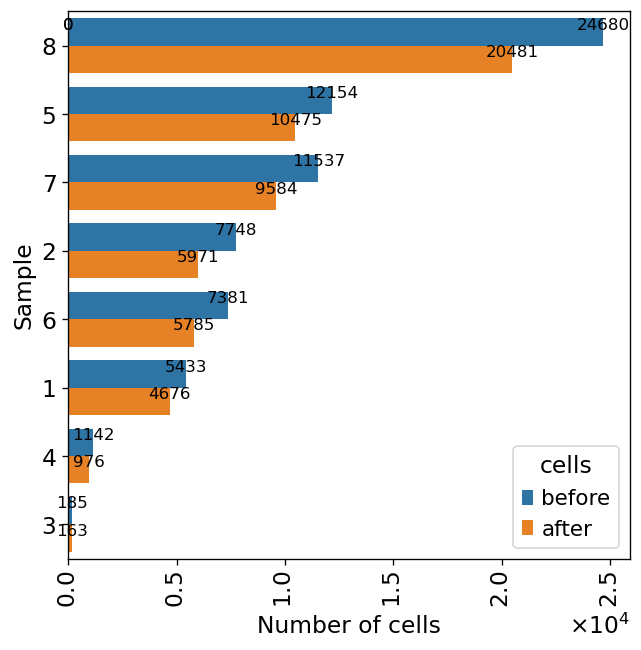

In [40]:

# df1 was created early in the analysis
df= pd.DataFrame(df1.obs['sample'].value_counts())
df['cells'] = 'before'
df2 = pd.DataFrame(jj.obs['sample'].value_counts())
df2['cells'] = 'after'

# Concatenate the DataFrames
comparing_datasets = pd.concat([df, df2])

# Create the bar plot
ax = sb.barplot(y=comparing_datasets.index,
                x=comparing_datasets['count'],  # Ensure 'count' is the correct column name
                hue=comparing_datasets['cells'],
                saturation=0.8)

# Add labels with values
for idx, p in enumerate(ax.patches):
    ax.annotate(f'{p.get_width():.0f}', (p.get_x() + p.get_width(), p.get_y() + p.get_height() - 0.2),
                ha='center', va='bottom', color='black', size=10)

plt.ticklabel_format(style='sci', axis='x', useMathText=True ,scilimits=(0,0))
plt.xticks(rotation=90)
plt.xlabel('Number of cells')
plt.ylabel('Sample')
plt.savefig('figures/original_cell_numbers_3.pdf')
plt.show()
